<a href="https://colab.research.google.com/github/Rony2019-2023/secure-cxr-detection-gbm-/blob/main/KNN_NEW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.io import imread
from skimage.transform import resize
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [ ]:
import os
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from skimage.io import imread
from skimage.transform import resize
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
# Define the directory paths for positive and negative images
covid_dir = '/content/drive/MyDrive/Mydataset/TrainData/COVID-19'
non_covid_dir = '/content/drive/MyDrive/Mydataset/TrainData/Normal'

In [ ]:
# Load COVID-19 images and create label array
covid_images = []
covid_labels = []
for img_name in os.listdir(covid_dir):
    img_path = os.path.join(covid_dir, img_name)
    img = imread(img_path)
    img_resized = resize(img, (256, 256)) # Resize image to same dimensions
    covid_images.append(img_resized)
    covid_labels.append(1) # Label COVID-19 images as 1

In [ ]:
# Load non-COVID-19 images and create label array
non_covid_images = []
non_covid_labels = []
for img_name in os.listdir(non_covid_dir):
    img_path = os.path.join(non_covid_dir, img_name)
    img = imread(img_path)
    img_resized = resize(img, (256, 256)) # Resize image to same dimensions
    non_covid_images.append(img_resized)
    non_covid_labels.append(0) # Label non-COVID-19 images as 0

In [ ]:
# Combine COVID-19 and non-COVID-19 images and labels into arrays
images = np.array(covid_images + non_covid_images)
labels = np.array(covid_labels + non_covid_labels)

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

In [ ]:
# Create k-NN classifier
k = 5 # number of neighbors
clf = KNeighborsClassifier(n_neighbors=k)
clf.fit(X_train.reshape(len(X_train), -1), y_train)


KNeighborsClassifier()

In [ ]:
# Predict on test set and calculate accuracy
y_pred = clf.predict(X_test.reshape(len(X_test), -1))
accuracy = accuracy_score(y_test, y_pred)

In [ ]:
# Predict on test set
y_pred = clf.predict(X_test.reshape(len(X_test), -1))

In [ ]:
# Calculate metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

In [ ]:
# Print results
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
print('Specificity:', specificity)
print('Accuracy:', accuracy)

Precision: 0.8
Recall: 0.5
F1 Score: 0.6153846153846154
Specificity: 0.9945945945945946
Accuracy: 0.9740932642487047


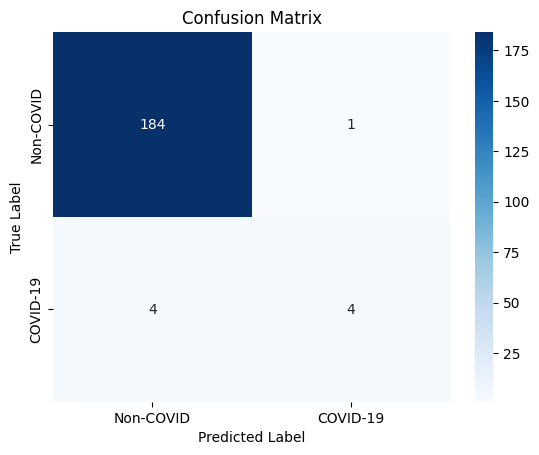

In [ ]:
# Predict on test set
y_pred = clf.predict(X_test.reshape(len(X_test), -1))

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Define labels for confusion matrix
labels = ['Non-COVID', 'COVID-19']

# Create seaborn heatmap with labels, title, and annotations
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels, fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

# Show plot
plt.show()

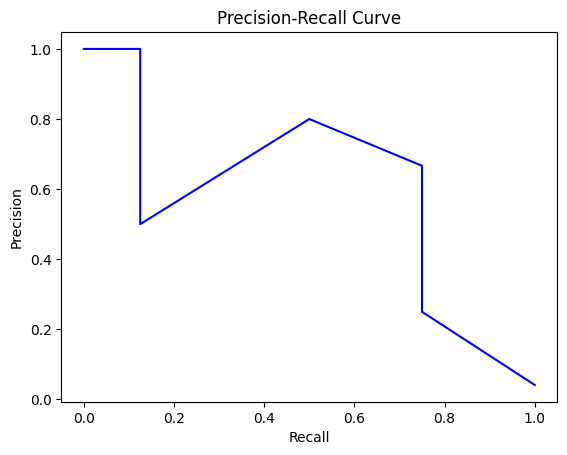

In [ ]:
# Predict on test set
y_scores = clf.predict_proba(X_test.reshape(len(X_test), -1))[:, 1]
y_true = y_test

# Calculate precision and recall for different probability thresholds
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

# Plot precision-recall curve
plt.plot(recall, precision, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

# Show plot
plt.show()


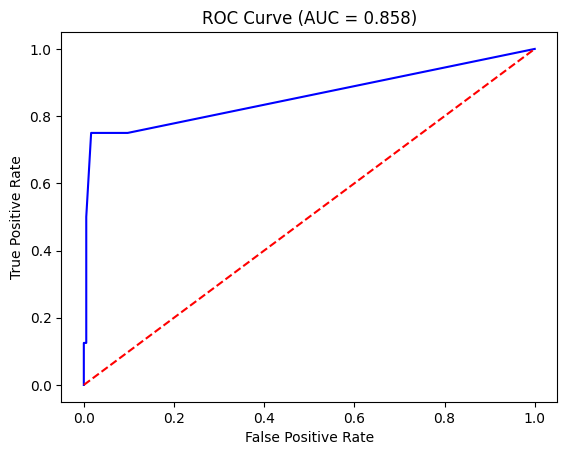

In [ ]:
# Predict on test set
y_scores = clf.predict_proba(X_test.reshape(len(X_test), -1))[:, 1]
y_true = y_test

# Calculate false positive rate, true positive rate, and probability thresholds
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# Calculate area under ROC curve
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, color='b')
plt.plot([0, 1], [0, 1], color='r', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (AUC = {:.3f})'.format(roc_auc))

# Show plot
plt.show()

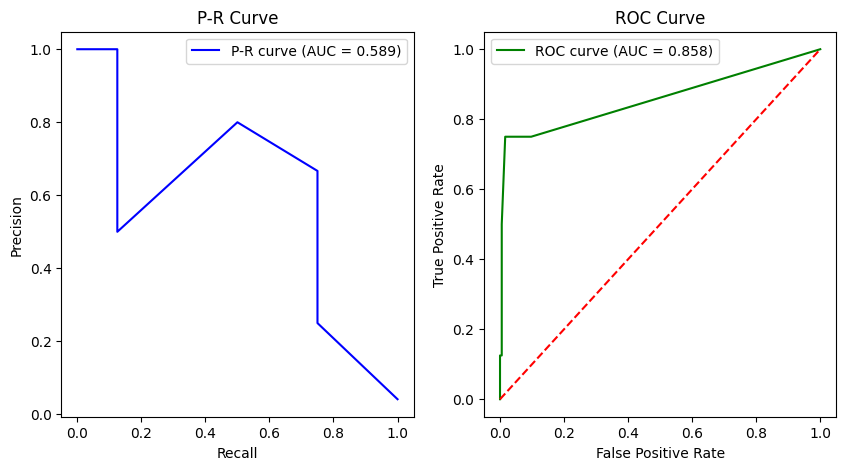

In [ ]:
# Predict on test set
y_scores = clf.predict_proba(X_test.reshape(len(X_test), -1))[:, 1]
y_true = y_test

# Calculate precision, recall, and probability thresholds for P-R curve
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

# Calculate false positive rate, true positive rate, and probability thresholds for ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_true, y_scores)

# Calculate area under curves
pr_auc = auc(recall, precision)
roc_auc = auc(fpr, tpr)

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5))

# Plot P-R curve in the first subplot
ax1.plot(recall, precision, color='b', label='P-R curve (AUC = {:.3f})'.format(pr_auc))
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('P-R Curve')
ax1.legend(loc='best')

# Plot ROC curve in the second subplot
ax2.plot(fpr, tpr, color='g', label='ROC curve (AUC = {:.3f})'.format(roc_auc))
ax2.plot([0, 1], [0, 1], color='r', linestyle='--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend(loc='best')

# Show the plot
plt.show()
